# Model Selection y Stepwise Regression

**Pregunta central:** Si tenemos 8 predictores disponibles, debemos usar todos? O hay una forma inteligente de elegir cuales incluir?

**Principio de Occam:** entre dos modelos con rendimiento similar, prefiere el mas simple.

En este notebook:
1. Veremos por que mas variables no siempre es mejor
2. Aprenderemos metricas que penalizan complejidad (R² ajustado, AIC, BIC)
3. Implementaremos seleccion por pasos (forward y backward)
4. Veremos como Ridge y Lasso hacen seleccion automatica
5. Compararemos todo con cross-validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/housing.csv", index_col="id")
outcome = "price"
all_predictors = [
    "square_meters",
    "age",
    "bedrooms",
    "bathrooms",
    "floor",
    "distance_to_center_km",
    "has_garage",
    "build_quality",
]
y = df[outcome]
print(f"Dataset: {len(df)} registros, {len(all_predictors)} predictores disponibles")
df.head()

Dataset: 100 registros, 8 predictores disponibles


,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality
id,,,,,,,,,
1,51,5,152700,2,1,2,4.7,0,5
2,52,44,132300,2,1,10,4.3,1,3
3,56,36,183200,2,1,1,6.6,1,6
4,57,6,170100,3,2,8,14.0,1,5
5,58,21,109500,2,1,1,18.0,1,5


---
## 1. El problema: mas variables = mejor?

Agregar variables **siempre** reduce el error in-sample (RMSE baja, R² sube). Pero eso no significa que el modelo generalice mejor.

In [3]:
predictor_sets = {
    "1 var (m2)": ["square_meters"],
    "2 vars": ["square_meters", "age"],
    "3 vars": ["square_meters", "age", "distance_to_center_km"],
    "5 vars": [
        "square_meters",
        "age",
        "distance_to_center_km",
        "bedrooms",
        "build_quality",
    ],
    "8 vars (todas)": all_predictors,
}

results = []
for name, preds in predictor_sets.items():
    X = df[preds]
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)

    # In-sample
    r2_in = r2_score(y, y_pred)
    rmse_in = np.sqrt(mean_squared_error(y, y_pred))

    # Cross-validation
    cv_r2 = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
    cv_mse = cross_val_score(
        LinearRegression(), X, y, cv=5, scoring="neg_mean_squared_error"
    )
    cv_rmse = np.sqrt(-cv_mse)

    results.append(
        {
            "Modelo": name,
            "P": len(preds),
            "R2 in-sample": f"{r2_in:.4f}",
            "R2 CV": f"{cv_r2.mean():.4f}",
            "RMSE in-sample": f"${rmse_in:,.0f}",
            "RMSE CV": f"${cv_rmse.mean():,.0f}",
        }
    )

pd.DataFrame(results)

,Modelo,P,R2 in-sample,R2 CV,RMSE in-sample,RMSE CV
0,1 var (m2),1,0.7441,0.1587,"$44,059","$43,888"
1,2 vars,2,0.7641,0.2002,"$42,308","$42,544"
2,3 vars,3,0.7987,0.3268,"$39,077","$39,418"
3,5 vars,5,0.8206,0.3809,"$36,895","$38,010"
4,8 vars (todas),8,0.8333,0.3521,"$35,561","$39,018"


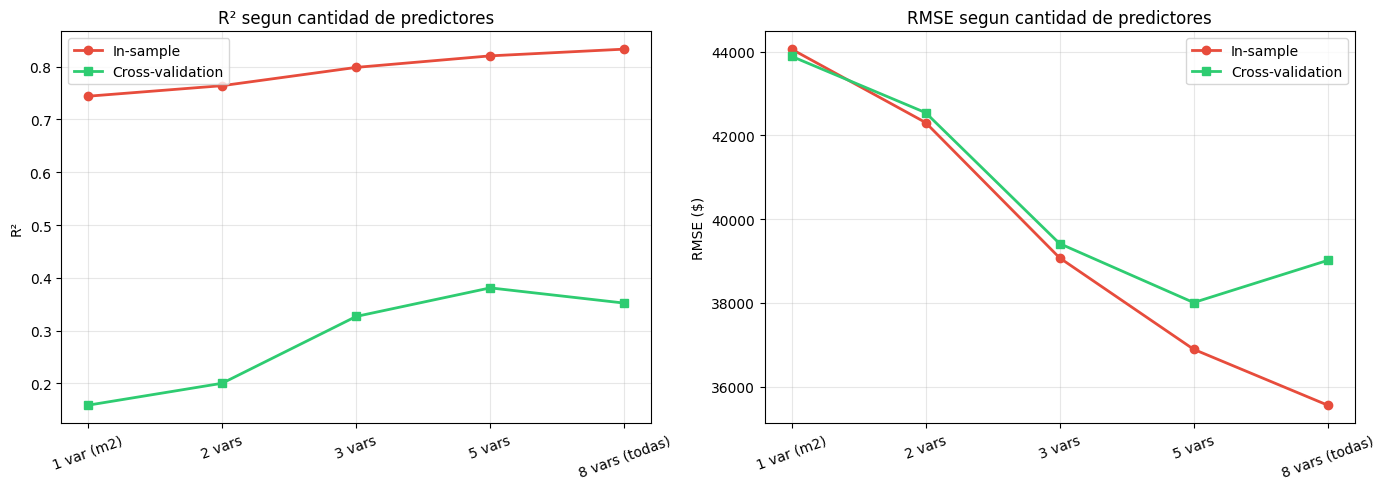

In-sample: siempre mejora al agregar variables (linea roja baja).
CV: llega un punto donde agregar variables NO mejora (linea verde se estanca o empeora).


In [4]:
# Visualizar: in-sample siempre mejora, CV no necesariamente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(predictor_sets.keys())
p_values = [len(v) for v in predictor_sets.values()]

r2_in_vals = []
r2_cv_vals = []
for preds in predictor_sets.values():
    X = df[preds]
    model = LinearRegression().fit(X, y)
    r2_in_vals.append(r2_score(y, model.predict(X)))
    r2_cv_vals.append(
        cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2").mean()
    )

axes[0].plot(names, r2_in_vals, "o-", color="#e74c3c", label="In-sample", linewidth=2)
axes[0].plot(
    names, r2_cv_vals, "s-", color="#2ecc71", label="Cross-validation", linewidth=2
)
axes[0].set_ylabel("R²")
axes[0].set_title("R² segun cantidad de predictores")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis="x", rotation=20)

rmse_in_vals = []
rmse_cv_vals = []
for preds in predictor_sets.values():
    X = df[preds]
    model = LinearRegression().fit(X, y)
    rmse_in_vals.append(np.sqrt(mean_squared_error(y, model.predict(X))))
    cv_mse = cross_val_score(
        LinearRegression(), X, y, cv=5, scoring="neg_mean_squared_error"
    )
    rmse_cv_vals.append(np.sqrt(-cv_mse).mean())

axes[1].plot(names, rmse_in_vals, "o-", color="#e74c3c", label="In-sample", linewidth=2)
axes[1].plot(
    names, rmse_cv_vals, "s-", color="#2ecc71", label="Cross-validation", linewidth=2
)
axes[1].set_ylabel("RMSE ($)")
axes[1].set_title("RMSE segun cantidad de predictores")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("In-sample: siempre mejora al agregar variables (linea roja baja).")
print(
    "CV: llega un punto donde agregar variables NO mejora (linea verde se estanca o empeora)."
)

---
## 2. R² Ajustado: penalizar la complejidad

R² normal **siempre sube** al agregar variables (aunque sean ruido). El R² ajustado corrige esto:

$$R^2_{adj} = 1 - (1 - R^2) \cdot \frac{n - 1}{n - P - 1}$$

Donde:
- `n` = numero de registros (100)
- `P` = numero de predictores

Si una variable nueva no aporta suficiente, el R² ajustado **baja** en vez de subir.

In [5]:
# Calculo manual de R² ajustado
n = len(df)

results = []
for name, preds in predictor_sets.items():
    X = df[preds]
    p = len(preds)
    model = LinearRegression().fit(X, y)
    r2 = r2_score(y, model.predict(X))

    # Formula del R² ajustado
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    results.append(
        {
            "Modelo": name,
            "P": p,
            "R²": round(r2, 4),
            "R² ajustado": round(r2_adj, 4),
            "Diferencia": round(r2 - r2_adj, 4),
        }
    )

adj_df = pd.DataFrame(results)
print(adj_df.to_string(index=False))
print(f"\nNota: la diferencia crece con mas predictores (la penalizacion es mayor).")

        Modelo  P     R²  R² ajustado  Diferencia
    1 var (m2)  1 0.7441       0.7415      0.0026
        2 vars  2 0.7641       0.7592      0.0049
        3 vars  3 0.7987       0.7924      0.0063
        5 vars  5 0.8206       0.8110      0.0095
8 vars (todas)  8 0.8333       0.8187      0.0147

Nota: la diferencia crece con mas predictores (la penalizacion es mayor).


In [6]:
# Verificar con statsmodels (que lo calcula automaticamente)
for name, preds in predictor_sets.items():
    X_sm = sm.add_constant(df[preds])
    result = sm.OLS(y, X_sm).fit()
    print(f"{name:20s} → R²={result.rsquared:.4f}  R²_adj={result.rsquared_adj:.4f}")

1 var (m2)           → R²=0.7441  R²_adj=0.7415
2 vars               → R²=0.7641  R²_adj=0.7592
3 vars               → R²=0.7987  R²_adj=0.7924
5 vars               → R²=0.8206  R²_adj=0.8110
8 vars (todas)       → R²=0.8333  R²_adj=0.8187


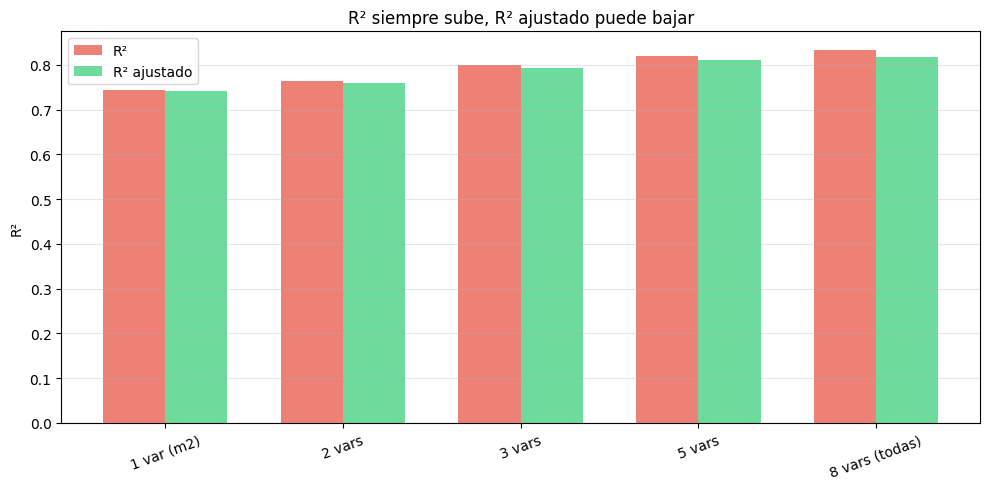

In [7]:
# Grafico: R² vs R² ajustado
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(adj_df))
width = 0.35

ax.bar(
    [x - width / 2 for x in x_pos],
    adj_df["R²"],
    width,
    label="R²",
    color="#e74c3c",
    alpha=0.7,
)
ax.bar(
    [x + width / 2 for x in x_pos],
    adj_df["R² ajustado"],
    width,
    label="R² ajustado",
    color="#2ecc71",
    alpha=0.7,
)

ax.set_xticks(x_pos)
ax.set_xticklabels(adj_df["Modelo"], rotation=20)
ax.set_ylabel("R²")
ax.set_title("R² siempre sube, R² ajustado puede bajar")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 3. AIC (Akaike Information Criteria)

AIC penaliza modelos con mas variables. La formula:

$$AIC = 2P + n \cdot \ln(RSS / n)$$

Donde:
- `P` = numero de parametros (predictores + intercepto)
- `n` = registros
- `RSS` = suma de residuos al cuadrado

**Menor AIC = mejor modelo.** Cada variable extra suma `+2` a la penalizacion.

In [8]:
# AIC manual vs statsmodels
results = []
for name, preds in predictor_sets.items():
    X_sm = sm.add_constant(df[preds])
    model = sm.OLS(y, X_sm).fit()

    # Calculo manual
    p = len(preds) + 1  # +1 por el intercepto
    rss = np.sum(model.resid**2)
    aic_manual = 2 * p + n * np.log(rss / n)

    results.append(
        {
            "Modelo": name,
            "P": len(preds),
            "AIC (manual)": round(aic_manual, 1),
            "AIC (statsmodels)": round(model.aic, 1),
            "R² adj": round(model.rsquared_adj, 4),
        }
    )

aic_df = pd.DataFrame(results)
print(aic_df.to_string(index=False))
print(
    f"\nNota: statsmodels usa una formula ligeramente diferente (incluye constantes extra),"
)
print(
    f"pero el ORDEN de los modelos es el mismo. Lo importante es comparar, no el valor absoluto."
)

        Modelo  P  AIC (manual)  AIC (statsmodels)  R² adj
    1 var (m2)  1        2142.7             2426.4  0.7415
        2 vars  2        2136.5             2420.3  0.7592
        3 vars  3        2122.7             2406.4  0.7924
        5 vars  5        2115.2             2399.0  0.8110
8 vars (todas)  8        2113.8             2397.6  0.8187

Nota: statsmodels usa una formula ligeramente diferente (incluye constantes extra),
pero el ORDEN de los modelos es el mismo. Lo importante es comparar, no el valor absoluto.


---
## 4. BIC (Bayesian Information Criteria)

BIC es similar a AIC pero penaliza **mas fuerte** las variables extra:

$$BIC = P \cdot \ln(n) + n \cdot \ln(RSS / n)$$

- AIC penaliza `+2` por variable
- BIC penaliza `+ln(n)` por variable (con n=100, eso es `+4.6`)

BIC tiende a elegir modelos **mas simples** que AIC.

In [9]:
results = []
for name, preds in predictor_sets.items():
    X_sm = sm.add_constant(df[preds])
    model = sm.OLS(y, X_sm).fit()
    results.append(
        {
            "Modelo": name,
            "P": len(preds),
            "AIC": round(model.aic, 1),
            "BIC": round(model.bic, 1),
        }
    )

compare_df = pd.DataFrame(results)
print(compare_df.to_string(index=False))

best_aic = compare_df.loc[compare_df["AIC"].idxmin(), "Modelo"]
best_bic = compare_df.loc[compare_df["BIC"].idxmin(), "Modelo"]
print(f"\nMejor segun AIC: {best_aic}")
print(f"Mejor segun BIC: {best_bic}")
print(f"\nPenalizacion por variable: AIC=+2, BIC=+ln({n})=+{np.log(n):.1f}")

        Modelo  P    AIC    BIC
    1 var (m2)  1 2426.4 2431.7
        2 vars  2 2420.3 2428.1
        3 vars  3 2406.4 2416.9
        5 vars  5 2399.0 2414.6
8 vars (todas)  8 2397.6 2421.0

Mejor segun AIC: 8 vars (todas)
Mejor segun BIC: 5 vars

Penalizacion por variable: AIC=+2, BIC=+ln(100)=+4.6


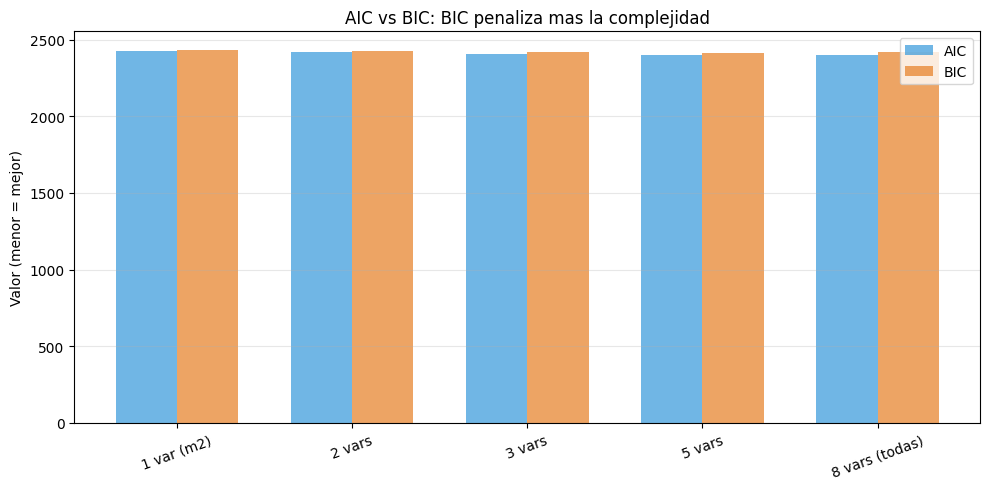

In [11]:
# Grafico AIC vs BIC
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(compare_df))
width = 0.35

ax.bar(
    [x - width / 2 for x in x_pos],
    compare_df["AIC"],
    width,
    label="AIC",
    color="#3498db",
    alpha=0.7,
)
ax.bar(
    [x + width / 2 for x in x_pos],
    compare_df["BIC"],
    width,
    label="BIC",
    color="#e67e22",
    alpha=0.7,
)

ax.set_xticks(x_pos)
ax.set_xticklabels(compare_df["Modelo"], rotation=20)
ax.set_ylabel("Valor (menor = mejor)")
ax.set_title("AIC vs BIC: BIC penaliza mas la complejidad")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 5. Forward Selection (seleccion hacia adelante)

Empieza **sin variables** y agrega una a una, eligiendo la que mas baje el AIC.

```
Paso 1: Probar cada variable sola → elegir la mejor
Paso 2: Con esa fija, probar agregar cada una de las restantes → elegir la mejor
Paso 3: Repetir hasta que ninguna variable nueva mejore el AIC
```

In [12]:
def calc_aic(y, X_with_const):
    """Calcula AIC usando statsmodels."""
    model = sm.OLS(y, X_with_const).fit()
    return model.aic


# Forward selection paso a paso
remaining = list(all_predictors)
selected = []
history = []

# AIC del modelo solo con intercepto
current_aic = sm.OLS(y, sm.add_constant(pd.DataFrame(index=df.index))).fit().aic
print(f"Inicio: AIC={current_aic:.1f} (solo intercepto)\n")

step = 0
while remaining:
    step += 1
    candidates = []

    for var in remaining:
        trial = selected + [var]
        X_trial = sm.add_constant(df[trial])
        aic = calc_aic(y, X_trial)
        candidates.append((var, aic))

    # Ordenar por AIC (menor es mejor)
    candidates.sort(key=lambda x: x[1])
    best_var, best_aic = candidates[0]

    if best_aic < current_aic:
        selected.append(best_var)
        remaining.remove(best_var)
        improvement = current_aic - best_aic
        current_aic = best_aic
        history.append(
            {
                "Paso": step,
                "Variable agregada": best_var,
                "AIC": round(best_aic, 1),
                "Mejora": round(improvement, 1),
            }
        )
        print(
            f"Paso {step}: + {best_var:25s} → AIC={best_aic:.1f} (mejora {improvement:.1f})"
        )
    else:
        print(f"\nPaso {step}: ninguna variable mejora el AIC. STOP.")
        break

print(f"\n--- Modelo final (forward) ---")
print(f"Variables: {selected}")
print(f"AIC: {current_aic:.1f}")

Inicio: AIC=2560.7 (solo intercepto)

Paso 1: + square_meters             → AIC=2426.4 (mejora 134.3)
Paso 2: + distance_to_center_km     → AIC=2412.1 (mejora 14.3)
Paso 3: + bathrooms                 → AIC=2405.4 (mejora 6.8)
Paso 4: + age                       → AIC=2400.0 (mejora 5.4)
Paso 5: + build_quality             → AIC=2397.8 (mejora 2.2)
Paso 6: + has_garage                → AIC=2395.6 (mejora 2.2)

Paso 7: ninguna variable mejora el AIC. STOP.

--- Modelo final (forward) ---
Variables: ['square_meters', 'distance_to_center_km', 'bathrooms', 'age', 'build_quality', 'has_garage']
AIC: 2395.6


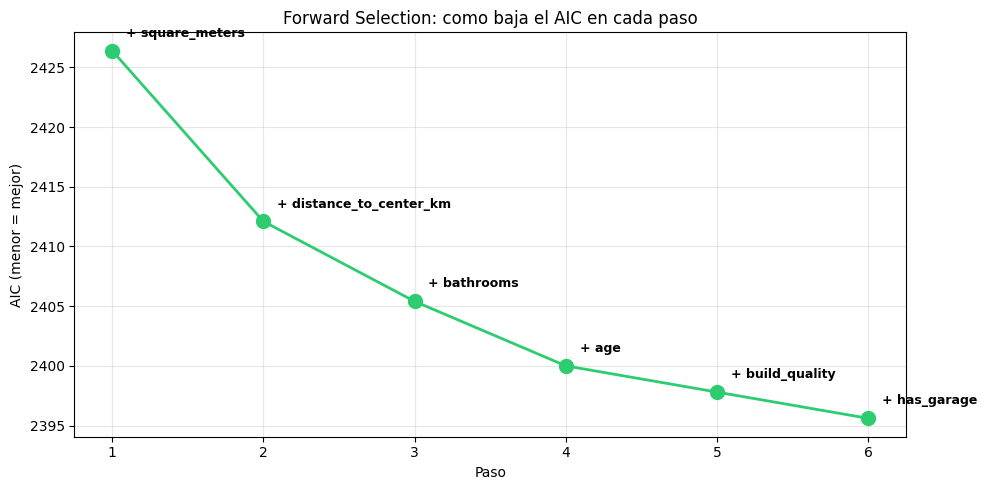

In [13]:
# Visualizar el camino del forward selection
if history:
    hist_df = pd.DataFrame(history)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        hist_df["Paso"],
        hist_df["AIC"],
        "o-",
        color="#2ecc71",
        linewidth=2,
        markersize=10,
    )

    for _, row in hist_df.iterrows():
        ax.annotate(
            f"+ {row['Variable agregada']}",
            (row["Paso"], row["AIC"]),
            textcoords="offset points",
            xytext=(10, 10),
            fontsize=9,
            fontweight="bold",
        )

    ax.set_xlabel("Paso")
    ax.set_ylabel("AIC (menor = mejor)")
    ax.set_title("Forward Selection: como baja el AIC en cada paso")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 6. Backward Elimination (eliminacion hacia atras)

Empieza con **todas las variables** y elimina una a una, quitando la que menos aporte (la que mas baje el AIC al ser removida).

```
Paso 1: Modelo completo (8 variables)
Paso 2: Probar quitar cada variable → eliminar la que menos duela
Paso 3: Repetir hasta que quitar cualquier variable empeore el AIC
```

In [14]:
# Backward elimination
selected_bw = list(all_predictors)
history_bw = []

X_full = sm.add_constant(df[selected_bw])
current_aic = sm.OLS(y, X_full).fit().aic
print(
    f"Inicio: AIC={current_aic:.1f} (modelo completo, {len(selected_bw)} variables)\n"
)

step = 0
while len(selected_bw) > 1:
    step += 1
    candidates = []

    for var in selected_bw:
        trial = [v for v in selected_bw if v != var]
        X_trial = sm.add_constant(df[trial])
        aic = calc_aic(y, X_trial)
        candidates.append((var, aic))

    # La variable cuya eliminacion da menor AIC
    candidates.sort(key=lambda x: x[1])
    worst_var, best_aic = candidates[0]

    if best_aic < current_aic:
        selected_bw.remove(worst_var)
        improvement = current_aic - best_aic
        current_aic = best_aic
        history_bw.append(
            {
                "Paso": step,
                "Variable eliminada": worst_var,
                "AIC": round(best_aic, 1),
                "Mejora": round(improvement, 1),
            }
        )
        print(
            f"Paso {step}: - {worst_var:25s} → AIC={best_aic:.1f} (mejora {improvement:.1f})"
        )
    else:
        print(f"\nPaso {step}: quitar cualquier variable empeora el AIC. STOP.")
        break

print(f"\n--- Modelo final (backward) ---")
print(f"Variables: {selected_bw}")
print(f"AIC: {current_aic:.1f}")

Inicio: AIC=2397.6 (modelo completo, 8 variables)

Paso 1: - floor                     → AIC=2395.8 (mejora 1.8)
Paso 2: - bedrooms                  → AIC=2395.6 (mejora 0.2)

Paso 3: quitar cualquier variable empeora el AIC. STOP.

--- Modelo final (backward) ---
Variables: ['square_meters', 'age', 'bathrooms', 'distance_to_center_km', 'has_garage', 'build_quality']
AIC: 2395.6


In [15]:
# Comparar forward vs backward
print("Forward selection eligio: ", selected)
print("Backward elimination eligio:", selected_bw)
print(f"\nCoinciden? {'Si' if set(selected) == set(selected_bw) else 'No'}")
print("\nNo siempre coinciden. Ambos son heuristicas, no garantizan el optimo global.")

Forward selection eligio:  ['square_meters', 'distance_to_center_km', 'bathrooms', 'age', 'build_quality', 'has_garage']
Backward elimination eligio: ['square_meters', 'age', 'bathrooms', 'distance_to_center_km', 'has_garage', 'build_quality']

Coinciden? Si

No siempre coinciden. Ambos son heuristicas, no garantizan el optimo global.


---
## 7. Regresion penalizada: Ridge y Lasso

En vez de agregar/quitar variables, estas tecnicas **reducen los coeficientes** de variables poco utiles.

| Metodo | Que hace | Resultado |
|--------|---------|----------|
| **Ridge** | Reduce coeficientes grandes | Todos quedan, pero mas chicos |
| **Lasso** | Reduce coeficientes a **cero** | Seleccion automatica de variables |

Ambos necesitan que las variables esten **en la misma escala** (estandarizadas).

In [17]:
# Estandarizar los predictores
X_all = df[all_predictors]
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_all), columns=all_predictors, index=df.index
)

print("Antes de estandarizar:")
print(X_all.describe().loc[["mean", "std"]].round(1))
print("\nDespues de estandarizar:")
print(X_scaled.describe().loc[["mean", "std"]].round(1))

Antes de estandarizar:
      square_meters   age  bedrooms  bathrooms  floor  distance_to_center_km  \
mean          123.4  23.9       4.0        2.4    8.2                   12.6   
std            47.7  14.6       1.6        1.1    4.3                    7.3   

      has_garage  build_quality  
mean         0.6            4.9  
std          0.5            1.5  

Despues de estandarizar:
      square_meters  age  bedrooms  bathrooms  floor  distance_to_center_km  \
mean           -0.0  0.0      -0.0        0.0   -0.0                   -0.0   
std             1.0  1.0       1.0        1.0    1.0                    1.0   

      has_garage  build_quality  
mean         0.0            0.0  
std          1.0            1.0  


In [18]:
# Comparar coeficientes: OLS vs Ridge vs Lasso
ols = LinearRegression().fit(X_scaled, y)
ridge = Ridge(alpha=10).fit(X_scaled, y)
lasso = Lasso(alpha=1000).fit(X_scaled, y)

coef_df = pd.DataFrame(
    {
        "Variable": all_predictors,
        "OLS": ols.coef_.round(0),
        "Ridge (α=10)": ridge.coef_.round(0),
        "Lasso (α=1000)": lasso.coef_.round(0),
    }
)

print(coef_df.to_string(index=False))
print(f"\nLasso pone a CERO las variables que no aportan = seleccion automatica.")

             Variable      OLS  Ridge (α=10)  Lasso (α=1000)
        square_meters  47715.0       36901.0         47521.0
                  age  -8982.0       -8682.0         -8384.0
             bedrooms  17725.0       23213.0         17612.0
            bathrooms  16242.0       18077.0         15099.0
                floor  -1564.0       -1224.0          -467.0
distance_to_center_km -18965.0      -16915.0        -17711.0
           has_garage   7705.0        7261.0          6662.0
        build_quality   8279.0        7472.0          7072.0

Lasso pone a CERO las variables que no aportan = seleccion automatica.


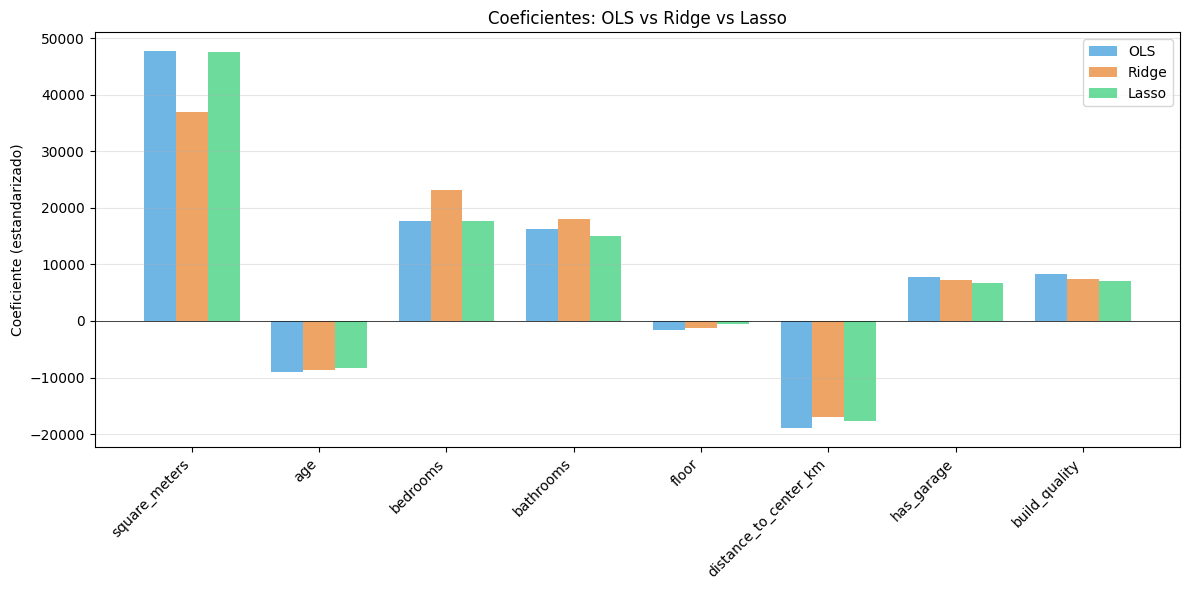

In [21]:
# Visualizar coeficientes
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(all_predictors))
width = 0.25

ax.bar(x_pos - width, coef_df["OLS"], width, label="OLS", color="#3498db", alpha=0.7)
ax.bar(x_pos, coef_df["Ridge (α=10)"], width, label="Ridge", color="#e67e22", alpha=0.7)
ax.bar(
    x_pos + width,
    coef_df["Lasso (α=1000)"],
    width,
    label="Lasso",
    color="#2ecc71",
    alpha=0.7,
)

ax.set_xticks(x_pos)
ax.set_xticklabels(all_predictors, rotation=45, ha="right")
ax.set_ylabel("Coeficiente (estandarizado)")
ax.set_title("Coeficientes: OLS vs Ridge vs Lasso")
ax.legend()
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [22]:
# LassoCV: encontrar el mejor alpha automaticamente con cross-validation
lasso_cv = LassoCV(cv=5, random_state=42).fit(X_scaled, y)

print(f"Mejor alpha encontrado por CV: {lasso_cv.alpha_:.2f}")
print(f"\nVariables seleccionadas por Lasso:")
for var, coef in zip(all_predictors, lasso_cv.coef_):
    status = "✓ incluida" if abs(coef) > 0.01 else "✗ eliminada"
    print(f"  {var:25s} coef={coef:>10,.0f}  {status}")

Mejor alpha encontrado por CV: 1509.60

Variables seleccionadas por Lasso:
  square_meters             coef=    47,449  ✓ incluida
  age                       coef=    -8,079  ✓ incluida
  bedrooms                  coef=    17,532  ✓ incluida
  bathrooms                 coef=    14,519  ✓ incluida
  floor                     coef=        -0  ✗ eliminada
  distance_to_center_km     coef=   -17,065  ✓ incluida
  has_garage                coef=     6,124  ✓ incluida
  build_quality             coef=     6,469  ✓ incluida


---
## 8. Comparacion final con Cross-Validation

La prueba definitiva: que modelo generaliza mejor? Comparemos todos los enfoques con 5-Fold CV.

In [23]:
# Definir los modelos a comparar
models = {
    "Modelo completo (8 vars)": (LinearRegression(), X_all),
    f"Forward selection ({len(selected)} vars)": (LinearRegression(), df[selected]),
    f"Backward elimination ({len(selected_bw)} vars)": (
        LinearRegression(),
        df[selected_bw],
    ),
    "Ridge (α=10)": (Ridge(alpha=10), X_scaled),
    f"Lasso (α={lasso_cv.alpha_:.0f})": (Lasso(alpha=lasso_cv.alpha_), X_scaled),
}

final_results = []
for name, (model, X_data) in models.items():
    cv_mse = cross_val_score(model, X_data, y, cv=5, scoring="neg_mean_squared_error")
    cv_rmse = np.sqrt(-cv_mse)
    cv_r2 = cross_val_score(model, X_data, y, cv=5, scoring="r2")

    final_results.append(
        {
            "Modelo": name,
            "RMSE (CV)": f"${cv_rmse.mean():,.0f} ± ${cv_rmse.std():,.0f}",
            "R² (CV)": f"{cv_r2.mean():.4f} ± {cv_r2.std():.4f}",
        }
    )

final_df = pd.DataFrame(final_results)
print(final_df.to_string(index=False))

                       Modelo         RMSE (CV)         R² (CV)
     Modelo completo (8 vars)  $39,018 ± $9,908 0.3521 ± 0.1703
   Forward selection (6 vars) $37,957 ± $10,695 0.3954 ± 0.1651
Backward elimination (6 vars) $37,957 ± $10,695 0.3954 ± 0.1651
                 Ridge (α=10) $38,392 ± $10,275 0.3729 ± 0.1815
               Lasso (α=1510)  $38,742 ± $9,940 0.3627 ± 0.1648


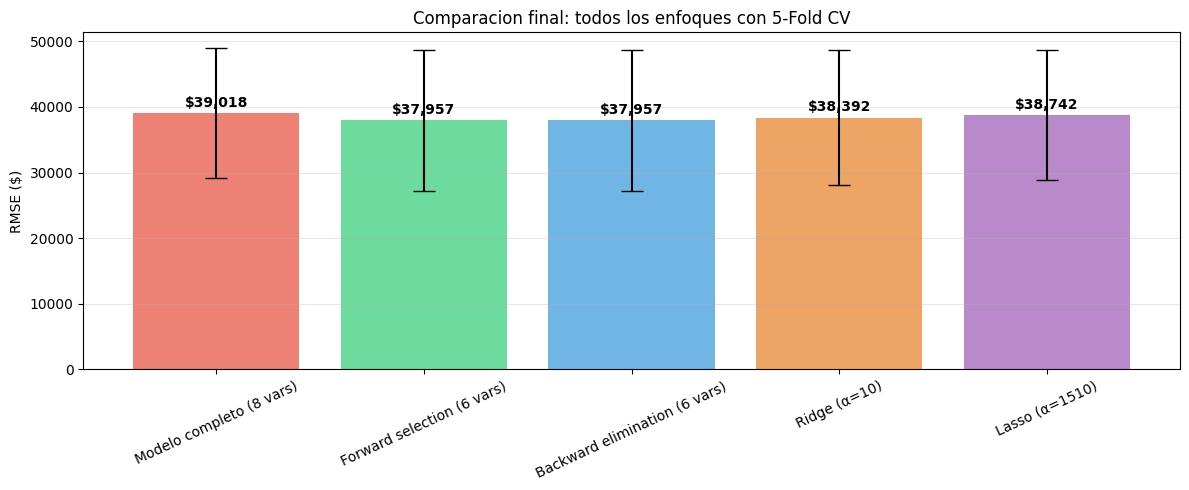

In [24]:
# Grafico final
fig, ax = plt.subplots(figsize=(12, 5))

rmse_means = []
rmse_stds = []
for name, (model, X_data) in models.items():
    cv_mse = cross_val_score(model, X_data, y, cv=5, scoring="neg_mean_squared_error")
    cv_rmse = np.sqrt(-cv_mse)
    rmse_means.append(cv_rmse.mean())
    rmse_stds.append(cv_rmse.std())

colors = ["#e74c3c", "#2ecc71", "#3498db", "#e67e22", "#9b59b6"]
bars = ax.bar(
    list(models.keys()), rmse_means, yerr=rmse_stds, capsize=8, color=colors, alpha=0.7
)

for bar, mean in zip(bars, rmse_means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f"${mean:,.0f}",
        ha="center",
        fontweight="bold",
    )

ax.set_ylabel("RMSE ($)")
ax.set_title("Comparacion final: todos los enfoques con 5-Fold CV")
ax.tick_params(axis="x", rotation=25)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## Resumen

| Herramienta | Que hace | Ventaja | Desventaja |
|-------------|---------|---------|------------|
| **R² ajustado** | Penaliza R² por cada variable extra | Simple, facil de interpretar | Solo penaliza un poco |
| **AIC** | Penaliza +2 por variable | Balance entre ajuste y complejidad | Es in-sample |
| **BIC** | Penaliza +ln(n) por variable | Prefiere modelos mas simples | Puede ser muy conservador |
| **Forward selection** | Agrega variables una a una | Empieza simple | Puede perder combinaciones |
| **Backward elimination** | Elimina variables una a una | Empieza completo | Costoso con muchas variables |
| **Ridge** | Reduce coeficientes (nunca a cero) | Maneja multicolinealidad | No elimina variables |
| **Lasso** | Reduce coeficientes (puede llegar a cero) | Seleccion automatica | Puede eliminar variables utiles |

**Regla de oro:** usa cross-validation como juez final, sin importar que metodo de seleccion uses.